*Developed by Emille Ishida (LPCA), May/2026 for the [in2p3 School of Statistics](https://indico.in2p3.fr/event/37891/)*  
*Original data from the [PLAsTiCC Kaggle data challenge](https://www.kaggle.com/c/PLAsTiCC-2018)*  
*Analysis taken from the [SNAD tutorials](https://coniferest.snad.space/en/latest/notebooks.html)*

# Astronomical Transient Time-Series

The original data set is composed by astronomical time-series observed in 6 different broad-band filters. 
Each multi-dimensional time-series is called a *light curve*.   
They represent the variation of brightness of a given astronomical source as a function of time and wavelength.

In this notebook, we will consider only events of the [supernova class](https://www.youtube.com/watch?v=-IjAwszbiO8), which correspond to the final cataclysmic event marking the end of life of massive stars or binary stellar systems. 

## The shape of the time-series and their astrophysical source

The figure below ([Kessler *et al.*, 2019](https://arxiv.org/pdf/1903.11756), figure 1), shows the different type of behaviors which can be associated to different astrophysical origins (right vertical axis).




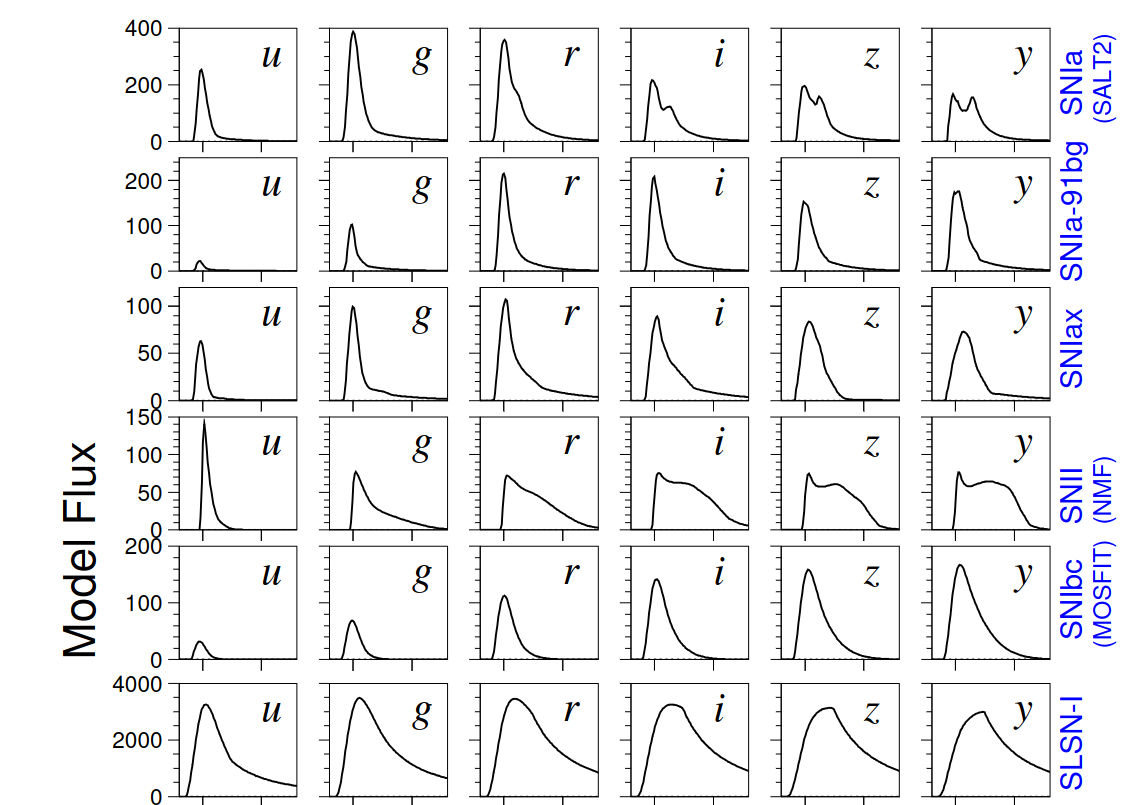

The continuous nature of the curves in the figure above does not depict the innhomogeneous sampling resulting from the telescope pointing strategy. In reality, the data will look more like the image below ([Kessler et al., 2019](https://arxiv.org/pdf/1903.11756), figure 16)

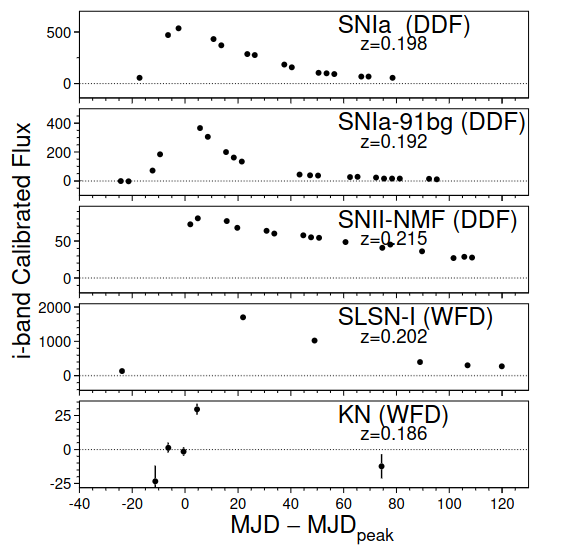

## Featurization

In order to use this data in a traditional machine learning scenario, it is necessary to transform each light curve in a set of features with fix dimensionality.  

In this notebook, we will use the as pre-processed by the SNAD team ([Ishida et al., 2021](https://www.aanda.org/articles/aa/pdf/2021/06/aa37709-20.pdf)). This includes:

- consider only SN-classes
- use only filters *g, r* and *i*
- only use observations between -20 and +100 days since maximum brightness in *r*-band
- fit each of the 3 filters using a [Gaussian Process](https://scikit-learn.org/stable/modules/gaussian_process.html) (GP) regression
- construct the final feature vector containing 374 features:  
-- the GP normalized flux interpolation between -20 and 120 days, sampling once a day (121 features per filter)  
-- parameters of the GP fit (9 features)  
-- the maximum log-likelihood of the fit  (1 feature)  
-- the light curve maximum flux (1 feature)


The processed data, along with an expert definition of what should be an anomaly are available within the [coniferest](https://coniferest.snad.space/en/latest/) package.

# The pre-processed data

In [1]:
from coniferest.datasets import plasticc_gp
import matplotlib.pylab  as plt
import numpy as np

In [2]:
# read results from Gaussian Process fit and expert definition of anomalies
data_all, labels = plasticc_gp()

In [3]:
# check the dimension of the dataset
data_all.shape

(7204, 374)

In [4]:
# check expert's anomaly definition
classes, counts = np.unique(labels, return_counts=True)

print('unique labels: ', classes)
print('number per label: ', counts)
print('fraction per label:', np.round(counts[0]/data_all.shape[0],2), np.round(counts[1]/data_all.shape[0],2))

unique labels:  [-1  1]
number per label:  [ 277 6927]
fraction per label: 0.04 0.96


Note that the anomalies are assigned the label `-1` and correspond to 4\% of the data.

## Visualize the parameter space

The plot below show the behaviour of the resulted  normalized interpolated light curves considered normal (gray) and those considered anomalous (red).  
The code in the cell bellow chooses `n_lc_plot` random objects to be displayed.  
*Remember that higher number consumes more memory. This is for visualization purposes only.*

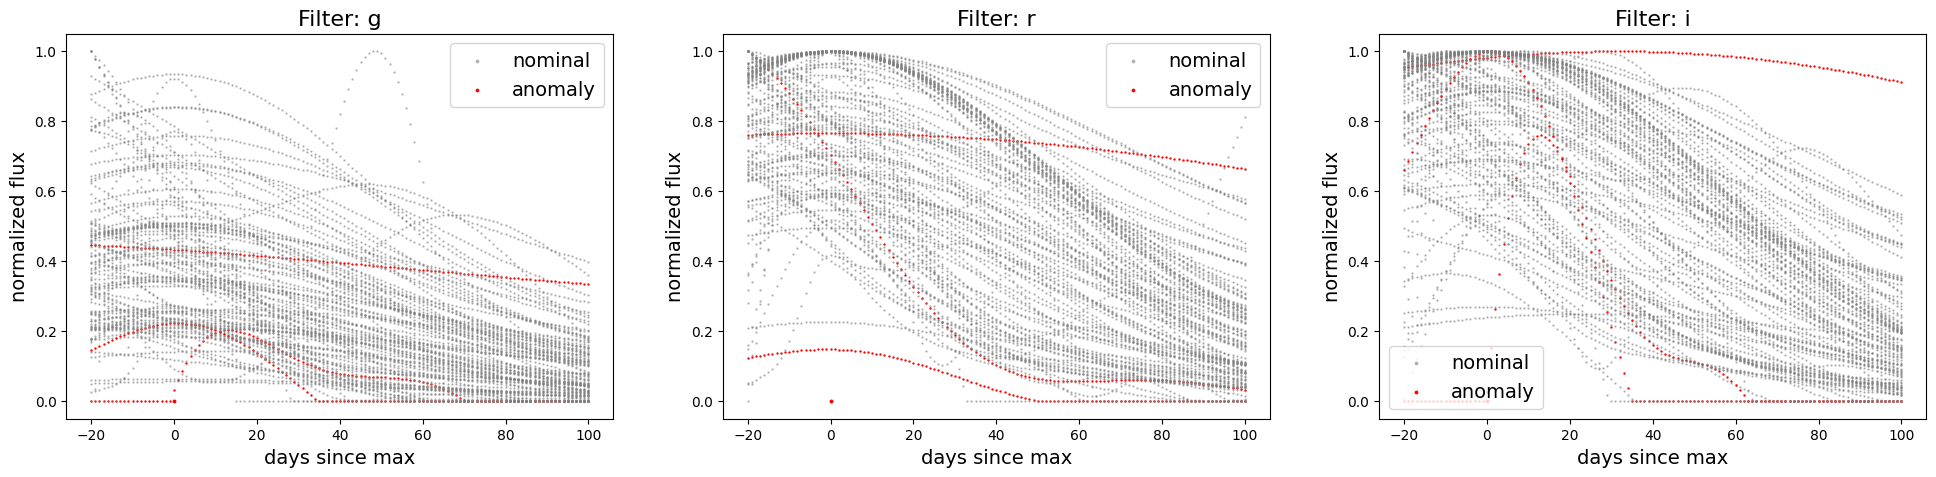

In [5]:
n_lc_plot = 100                     # number of light curves you want to see in this plot


end = 11                            # number of parameters from the GP-fit + bad fit epochs
done = []
leg_nominal = []
leg_anomaly = []

filters = ['g', 'r', 'i']          # LSST filters
n_days = 121                       # number of observed days per light curve


plt.figure(figsize=(24,5))

for i in range(n_lc_plot):
    indx = np.random.choice(np.arange(data_all.shape[0]))        # random choice of objects
    if indx not in done and min(data_all[indx][:-end]) >= 0:     # ignore problematic data with negative fluxes
        if labels[indx] == 1:                                # if nominal, gray
            c = 'gray'
            alpha = 0.5
            name = 'nominal'
        elif labels[indx] == -1:                             # if anomaly, red
            c = 'red'
            alpha=1
            name = 'anomaly'
        for j in range(1, 4):
            plt.subplot(1,3,j)
            plt.title('Filter: ' + filters[j-1] , fontsize=16)
            plt.scatter(np.arange(n_days)-20, data_all[indx][(j-1)*n_days:j*n_days], 
                        s=0.5, color=c, alpha=alpha)
            plt.xlabel('days since max', fontsize=14)
            plt.ylabel('normalized flux', fontsize=14)

            # the block below ensures labels are displayed only once per panel
            if name == 'anomaly' and j not in leg_anomaly:
                plt.scatter([0],[0], s=3, color=c, alpha=alpha, label=name)
                plt.legend(fontsize=14)
                leg_anomaly.append(j)
            elif name == 'nominal' and j not in leg_nominal:
                plt.scatter([0],[0], s=3, color=c, alpha=alpha, label=name)
                plt.legend(fontsize=14)
                leg_nominal.append(j)
        done.append(indx)

plt.show()

The distribution of the 11 extra parameters (9 from the GP fit + the maximum log-likelihood and max flux) can be visualized in the plot below.

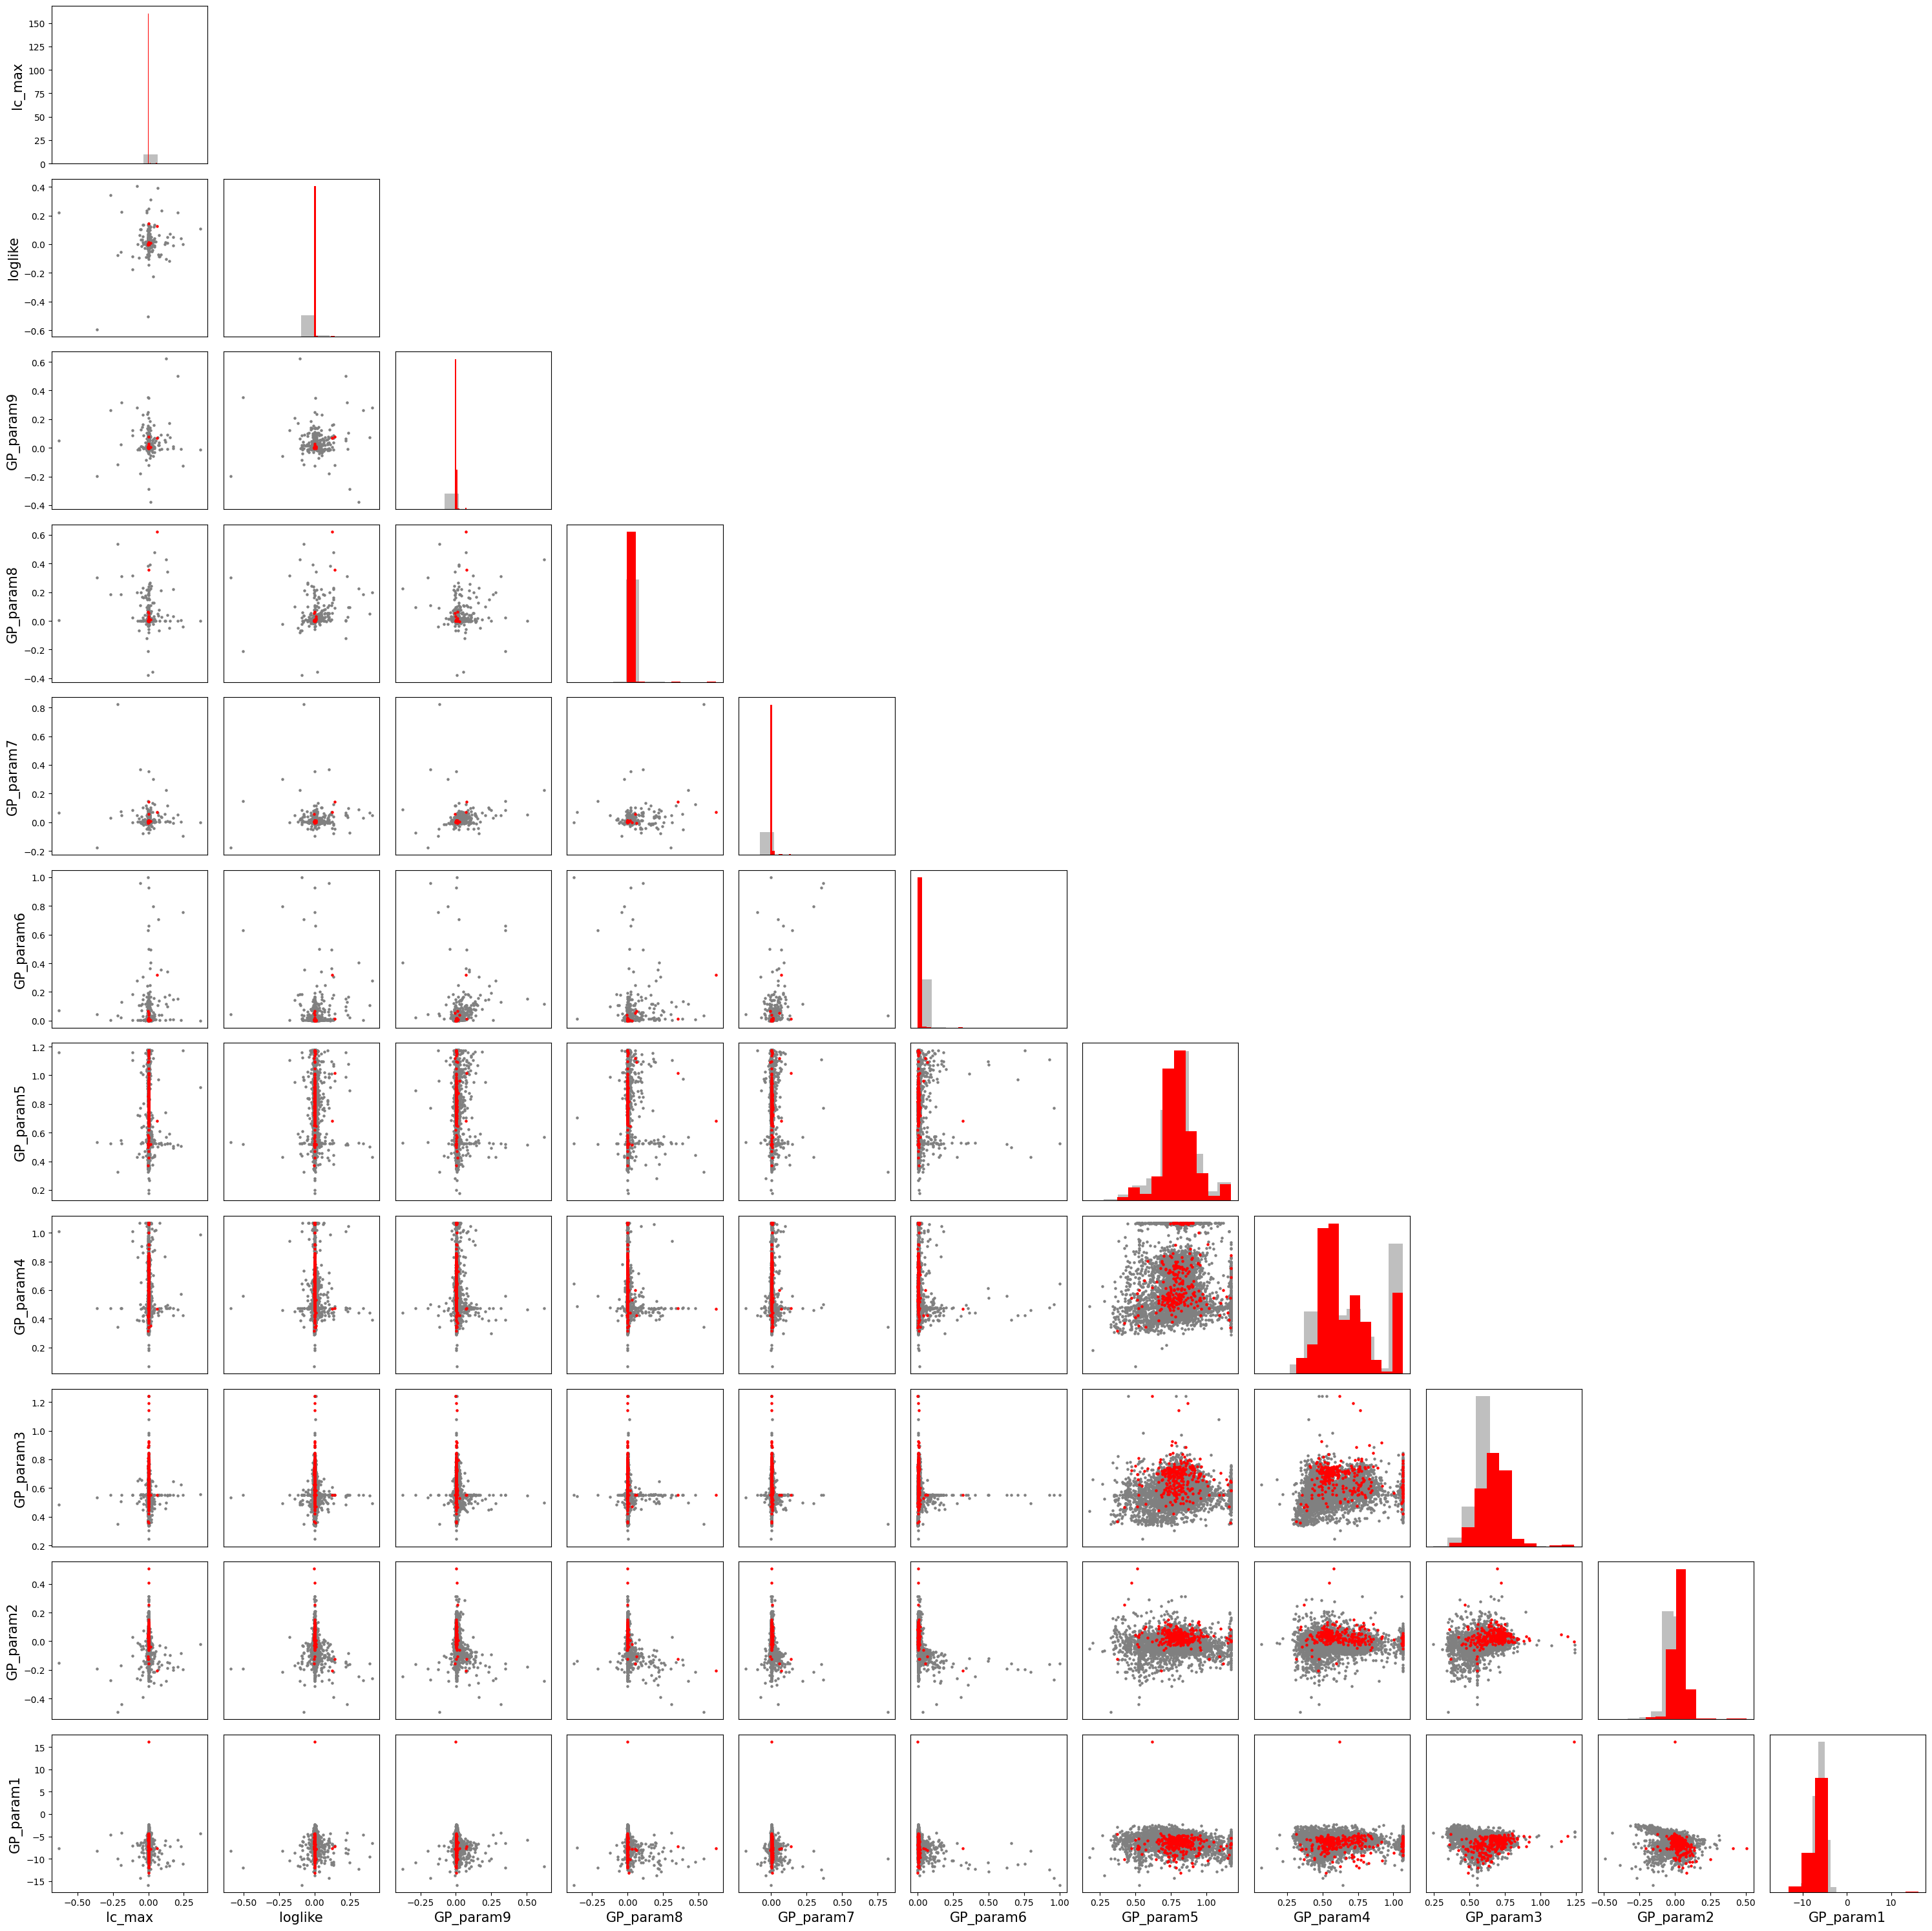

In [6]:
def plot_scatter(data, mask=None, anomaly_size=5):
    """
    Plot the GP best fit, log_likelihood and lc_max parameter space. 

    Parameters
    ----------
    data: np.array
        each line should be an object, each column a parameter. 
        There should be 374 columns. 
    mask: str, None or np.array
        Mask identifying the anomalies which will be shown in red. 
        If 'original', all experts record labels are identified
        If None, all points are plotted as nominals. 
        If an array of booleans, True elements identifying anomalies.
        Default is None.
    anomaly_size: int
        Point size of anomalies. Default is 5. 

    Returns
    -------
        Scatter plot.
    """
    
    names = ['GP_param' + str(i) for i in range(1, 10)] + ['loglike', 'lc_max']     # vector with parameter names

    if isinstance(mask, str) and mask == 'original':
        anomaly_mask = labels == -1
    elif mask is None:
        anomaly_mask = np.array([False for i in range(data.shape[0])])
    else:
        anomaly_mask = mask                           # mask given by the user
    nominal_size = 5                                 # point size of nominals

    npanels = 11                                     # number of parameters

    plt.figure(figsize=(30,30))

    for i in range(1, npanels + 1):
        for j in range(1, npanels + 1):
            if i > j:
                ax = plt.subplot(npanels,npanels,(i - 1)* npanels + j)
                plt.scatter(data[~anomaly_mask][:,-j], data[~anomaly_mask][:,-i], s=nominal_size, color='gray')
                plt.scatter(data[anomaly_mask][:,-j], data[anomaly_mask][:,-i], s=anomaly_size, color='red')

                if j == 1:
                    plt.ylabel(names[-i], fontsize=15)
                else: 
                    ax.yaxis.set_visible(False)

                if i == npanels:
                    plt.xlabel(names[-j], fontsize=15)
                else:
                    ax.xaxis.set_visible(False)

            elif i == j:
                ax = plt.subplot(npanels,npanels,(i - 1)* npanels + j)
                plt.hist(data[~anomaly_mask][:,-j], color='gray', alpha=0.5, density=True)
                if mask is not None:
                    plt.hist(data[anomaly_mask][:,-j], color='red', density=True)

                if j == npanels:
                    ax.yaxis.set_visible(False)
                    plt.xlabel(names[-j], fontsize=15)
                elif j == 1:
                    plt.ylabel(names[-j], fontsize=15)
                    ax.xaxis.set_visible(False)
                else:
                    ax.xaxis.set_visible(False)
                    ax.yaxis.set_visible(False)
                
    plt.tight_layout()
    plt.show()

plot_scatter(data_all, mask='original')

# Food for thought

We discussed 2 definitions of anomaly:  

1. *"An anomaly is an observation which deviates so much from the other observations 
as to arouse suspicions that it was generated by a different mechanism"*, Hawkins (1980)

2. An isolated element in a given parameter space, indicating its uniqueness. 


### Looking at the two plots and definitions above, how do you interpret the expert's definition of anomaly?  
### Considering the second anomaly definition and the scatter plot above, which set of points would you identify as anomalous by eye?  
### What difficulties does the expert definition of anomaly imposes to the use of out-of-the-box ML strategies?

--------------------------------------------------------------------------------------------

# Comparing different anomaly detection strategies

Choose at least 2 different anomaly detection strategies available within [scikit-learn](https://scikit-learn.org/stable/) and compare the top 20 anomalies identified by them.  

Remember that the objects shold be identified by their position in the initial data matrix.

**Example: [Isolation Forest](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.IsolationForest.html)**

In [7]:
from sklearn.ensemble import IsolationForest

clf_iso = IsolationForest(random_state=42, n_estimators=100)    # define a forest with 100 trees
clf_iso.fit(data_all)                                               # construct the forest
scores_iso = clf_iso.score_samples(data_all)                            # calculate anomaly scores

Remember that the most anomalous object has the **most negative** anomaly score.

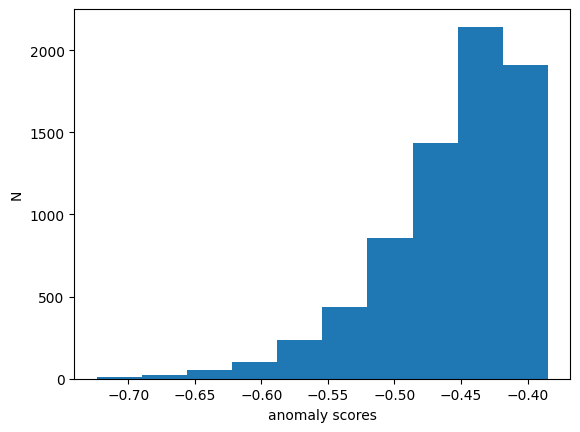

In [8]:
# visualize the score distribution

plt.figure()
plt.hist(scores_iso)
plt.xlabel('anomaly scores')
plt.ylabel('N')
plt.show()

In [9]:
# order scores
indx = np.argsort(scores_iso)

# score of most anomalous object
scores_iso[indx[0]]

np.float64(-0.7234772057805963)

In [10]:
# score of the most normal object
scores_iso[indx[-1]]

np.float64(-0.3847197505757399)

In [11]:
# the indx vector gives us the position of the most anomalous objects
indx[:20]

array([2921,  891, 2030, 6615, 1285, 1584, 3339, 1494, 1375, 1221, 6142,
       4379, 3799, 7176, 1439, 2248,  799,  252, 1820, 6770])

**[TODO] Estimate anomaly scores and identify the position of the 20 most anomalous objects found by at least 1 other strategy:**  
PS: if you wish to try more than one, the more the merrier!

Examples of available strategies in scikit-learn:  
- [OneClassSVM](https://scikit-learn.org/stable/modules/generated/sklearn.svm.OneClassSVM.html#sklearn.svm.OneClassSVM)
- [LocalOutlierFactor](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.LocalOutlierFactor.html#sklearn.neighbors.LocalOutlierFactor)
- [EllipticEnvelope](https://scikit-learn.org/stable/modules/generated/sklearn.covariance.EllipticEnvelope.html#sklearn.covariance.EllipticEnvelope)


Visual comparison of these methods in a toy dataset is shown [here](https://scikit-learn.org/stable/auto_examples/miscellaneous/plot_anomaly_comparison.html).

**[TODO] From the top anomalies you identified, check the labels given to them by the expert, which are inside the *labels* vector**  
**[Question] Do the different strategies identify the same elements as anomalous?**  
**[Question] How many of the top 20 anomalies you found were also identified as such by the expert?**

# Incorporating the expert feedback

In dealing with real data from fundamental sciences, many times the expert does not posses a mathematical definition of the type of anomaly they want to see. In this context, the machine should incorporate expert feedback and adapt the algorithm accordingly as new information is provided. 

The [coniferest package](https://coniferest.snad.space/en/latest/index.html) provides an environment where active anomaly detection can be performed using 2 different strategies: [Active Anomaly Discovery (AAD)](https://arxiv.org/pdf/1909.13260) and [PineForest](https://www.sciencedirect.com/science/article/abs/pii/S2213133725000332?via%3Dihub).  

The framework also provides an optimized version of the Isolation Forest Algorithm. 

### Example using PineForest

In the example below, the code will ask for your opinion for the first `n_loops` objects with highest anomaly scores, starting from an Isolation Forest model.  

Since it is difficult to visualize a space with 374 dimensions, for each iteration we show the plot placing the anomaly candidate and the show the expert label so you can compare your judgement with theirs. 

In [18]:
# define number of loops to screen
# [IMPORTANT] this data set is known to start reacting after a minimum of 20 loops
n_loops = 2

In [19]:
# define a vector to keep track of the position of each object as labels
names = np.arange(data_all.shape[0])

In [20]:
plot_scatter_flag = False                       # Set this to False if you want to suppress the big scatter plot

In [21]:
# This cell has a few tools that allow you to interact with the learning loop

import csv
from coniferest.pineforest import PineForest
from coniferest.session import Session
from coniferest.label import Label
from coniferest.session.callback import (
    TerminateAfter, prompt_decision_callback,
)

# declare the model parameters
model_ex1 = PineForest(
    # Use 1024 trees, a trade-off between speed and accuracy
    n_trees=1024,
    # Fix random seed for reproducibility
    random_seed=42,
)

# get the label given by the expert to help your decision
def my_decision_callback(metadata, data, session, data_all=data_all,
                        plot_scatter_flag=plot_scatter_flag):
    print(f"Candidate presented: {metadata}")  # Identify candidate
    print(f"Expert label: {labels[metadata]}")

    if plot_scatter_flag:
        mask = names == metadata
        plot_scatter(data_all, mask, anomaly_size=150)   # plot GP parameters
    
    # your decision logic
    answer = input("Is this an anomaly? [y/n]: ")
    return Label.ANOMALY if answer.lower() == "y" else Label.REGULAR

# record your answers
class SaveDecisionsCallback:
    def __init__(self):
        self.filename = input("Enter filename to save decisions: ")
        # Write header
        with open(self.filename, 'w') as f:
            f.write("metadata,decision\n")
            
    def print_report(self, s):
        with open(self.filename, "w", newline="") as f:
            writer = csv.writer(f)
            writer.writerow(["Object", "Expert_label", "Decision", "Score"])
            for idx, label in s.known_labels.items():
                writer.writerow([names[idx], labels[idx], label.name, s.scores[idx]]) 
        print(f"Decisions saved to {self.filename}")


In [ ]:
save_callback = SaveDecisionsCallback()  # will prompt for filename 

# call the session
session_ex1 = Session(
    # Data to use
    data=data_all,
    # Metadata to help an expert (you!)
    metadata=names,
    model=model_ex1,
    # Ask expert interactively
    decision_callback=my_decision_callback,
    # Stop after `n` objects
    on_decision_callbacks=TerminateAfter(n_loops),
)

session_ex1.run()                               # run iteractive loop
save_callback.print_report(session_ex1)         # save answers to file

**[TODO] Set up a similar cell that uses the AADForest algorithm**  
**[TODO] compare results from the Isolation Forest, AADForest, PineForest algorithm for the first 30 objects.**

# Questions

**Which algorithm performs better after 30 anomalies are identified?**  
**By fine tunning the hyperparameters of the model, can you optimize the number of anomalies found by the algorithm that the expert wants to see?**
**How many anomalies your best version of the algorithm was able to find after 30 loops?**


Extra resources that might help in the tasks above:

- The [Coniferest tutorial](https://coniferest.snad.space/en/latest/tutorial.html) has a section on *Use prior knowledge with known labels¶*  which might help you use previous answers from saved files.

- A full-fledge example of this exercise can be found here, and give you an idea of the type of optimization you might aim at